In [79]:
%pip install nbformat
%run ../Lanes.ipynb

Note: you may need to restart the kernel to use updated packages.
Test 1: Empty Road
  Expected flow = 0, Actual flow = 1.7
  Expected jam fraction = 0, Actual jam fraction = 0.0
  FAIL

Test 2: Full Road
  Expected jam fraction = 1, Actual jam fraction = 1.000
  PASS
Totoal Average Flow: 0.5127272727272728
Total Jamming Fraction: 0.0978457852620532
[[-1]
 [ 2]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 1]
 [-1]
 [-1]
 [-1]
 [ 0]
 [-1]
 [-1]
 [-1]
 [-1]
 [ 4]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [ 5]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [ 0]
 [-1]
 [ 1]
 [ 3]
 [-1]
 [-1]
 [ 3]
 [-1]
 [-1]
 [-1]
 [-1]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [-1]
 [-1]
 [ 2]
 [ 2]]


## Jamming and Flow Average
This plots the average flow and jamming ratio over simulations with varying densities.

In [130]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

jam_threshold = 0.2
density_range = np.linspace(0.01,0.99,1000)
lane_count = 6
cell_number = 1000
simulation_time = 1000

density = np.meshgrid(density_range)

def stat_2d(density):
    global pbar
    test_grid = Multi_Lane_Traffic(cells = cell_number, lanes = lane_count, density = density, vmax=5, tolerance_limit=2e-3)
    test_grid.simulate(simulation_time)
    pbar.update(1)
    return test_grid.history_jam_fraction(), test_grid.history_average_flow()

statistics_2d = np.vectorize(stat_2d)
with tqdm(total=len(density_range)) as pbar:
            jamming_fractions, average_flows = statistics_2d(density)

"""
for density in tqdm(density_range):
    testing_grid = Multi_Lane_Traffic(cells=1000, lanes = lane_count, density= density, random_state=0,vmax=5)
    testing_grid.simulate(100)
    jamming_fractions.append(testing_grid.history_jam_fraction())
    average_flows.append(testing_grid.history_average_flow())
"""

1001it [08:07,  2.06it/s]                          


'\nfor density in tqdm(density_range):\n    testing_grid = Multi_Lane_Traffic(cells=1000, lanes = lane_count, density= density, random_state=0,vmax=5)\n    testing_grid.simulate(100)\n    jamming_fractions.append(testing_grid.history_jam_fraction())\n    average_flows.append(testing_grid.history_average_flow())\n'

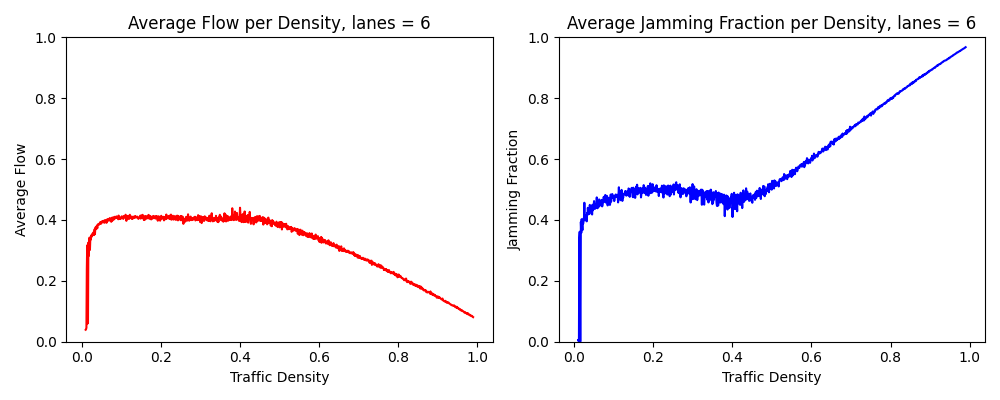

In [131]:


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))


axes[0].plot(density[0],average_flows[0], label = "Average Flow", color = 'red')
axes[0].set_title("Average Flow per Density, lanes = {}".format(lane_count))
axes[0].set_ylim(0,1)
axes[0].set_xlabel("Traffic Density")
axes[0].set_ylabel("Average Flow")

axes[1].plot(density[0],jamming_fractions[0], label = "Jamming Fraction", color = 'blue')
axes[1].set_title("Average Jamming Fraction per Density, lanes = {}".format(lane_count))
axes[1].set_ylim(0,1)
axes[1].set_xlabel("Traffic Density")
axes[1].set_ylabel("Jamming Fraction")

plt.tight_layout()
plt.show()

## Average Flow & Jamming Fraction VS Density and Lane Number
For this part we varied the densiy as usual, but also introduced variations to the number of lanes.

In [183]:
cell_number = 1000
jam_threshold = 0.2
density_range = np.linspace(0.01,0.99,100)
lane_range = range(1,17)
simulation_time = 100

density, lane = np.meshgrid(density_range,lane_range)

def stat_3d(density, lane):
    global pbar
    test_grid = Multi_Lane_Traffic(cells = cell_number, lanes = lane, density = density, vmax=5)
    test_grid.simulate(simulation_time)
    pbar.update(1)
    return test_grid.history_jam_fraction(), test_grid.history_average_flow()

statistics_3d = np.vectorize(stat_3d)
with tqdm(total=len(lane_range)*len(density_range)) as pbar:
            jamming_fractions, average_flows = statistics_3d(density, lane)



1601it [33:15,  1.25s/it]                          


This portion plots our data in 3D

Note: you may need to restart the kernel to use updated packages.


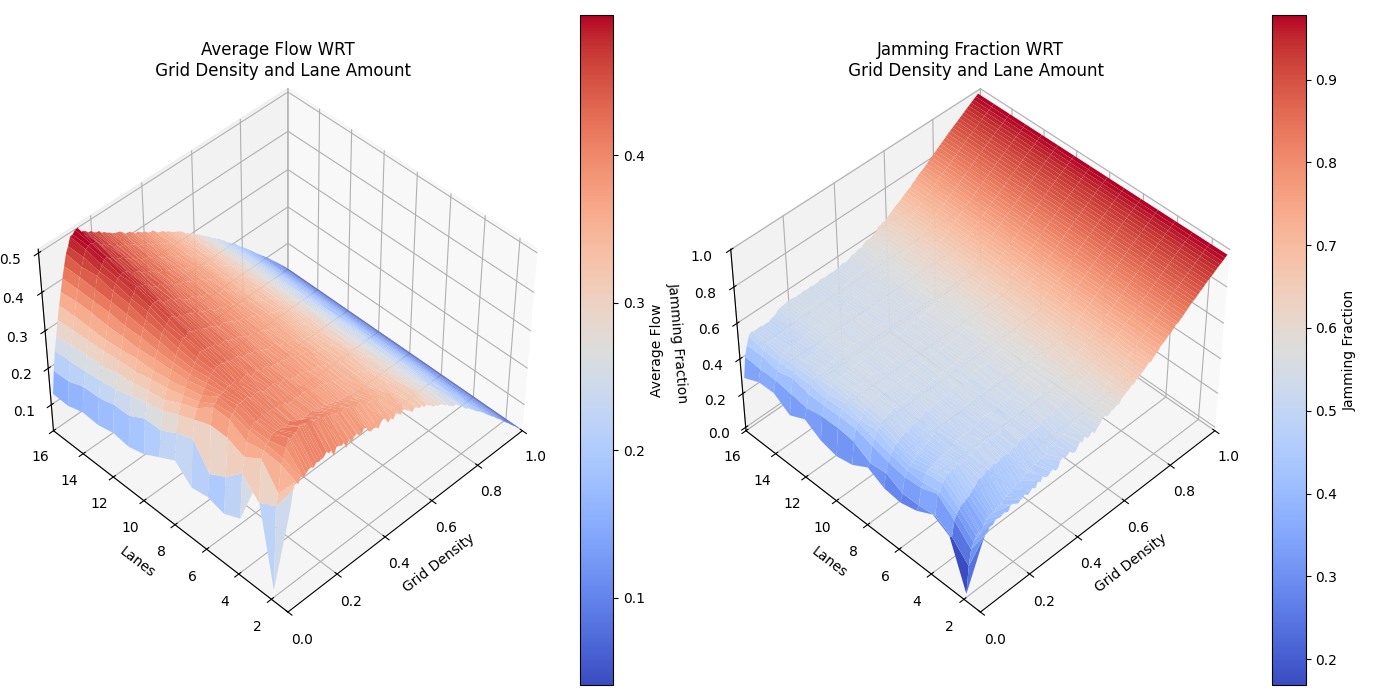

In [185]:
%pip install matplotlib
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(122, projection = '3d')


ay = fig.add_subplot(121, projection = '3d')

cf1 = ay.plot_surface(density, lane, average_flows, rstride=1, cstride=1, cmap='coolwarm',
                       linewidth=0, antialiased=True)

ay.set_xlabel('Grid Density')
ay.set_ylabel('Lanes')
ay.set_zlabel('Average Flow')
ay.set_title('Average Flow WRT \n Grid Density and Lane Amount')
ay.set_xlim(0,1)
ay.set_ylim(1,16)

cf2 = ax.plot_surface(density, lane, jamming_fractions, rstride=1, cstride=1, cmap='coolwarm',
                       linewidth=0, antialiased=True)

ax.set_xlabel('Grid Density')
ax.set_ylabel('Lanes')
ax.set_zlabel('Jamming Fraction')
ax.set_title('Jamming Fraction WRT \n Grid Density and Lane Amount')
ax.set_xlim(0,1)
ax.set_ylim(1,16)

fig.colorbar(cf1, ax = ay, label='Average Flow')
fig.colorbar(cf2, ax = ax, label='Jamming Fraction')

ay.view_init(45,-45 -90,0)
ax.view_init(45,-45 -90,0)


plt.subplots_adjust(wspace=0.5)
plt.tight_layout()
plt.show()

This portion Plots the data on a 2d colormap.

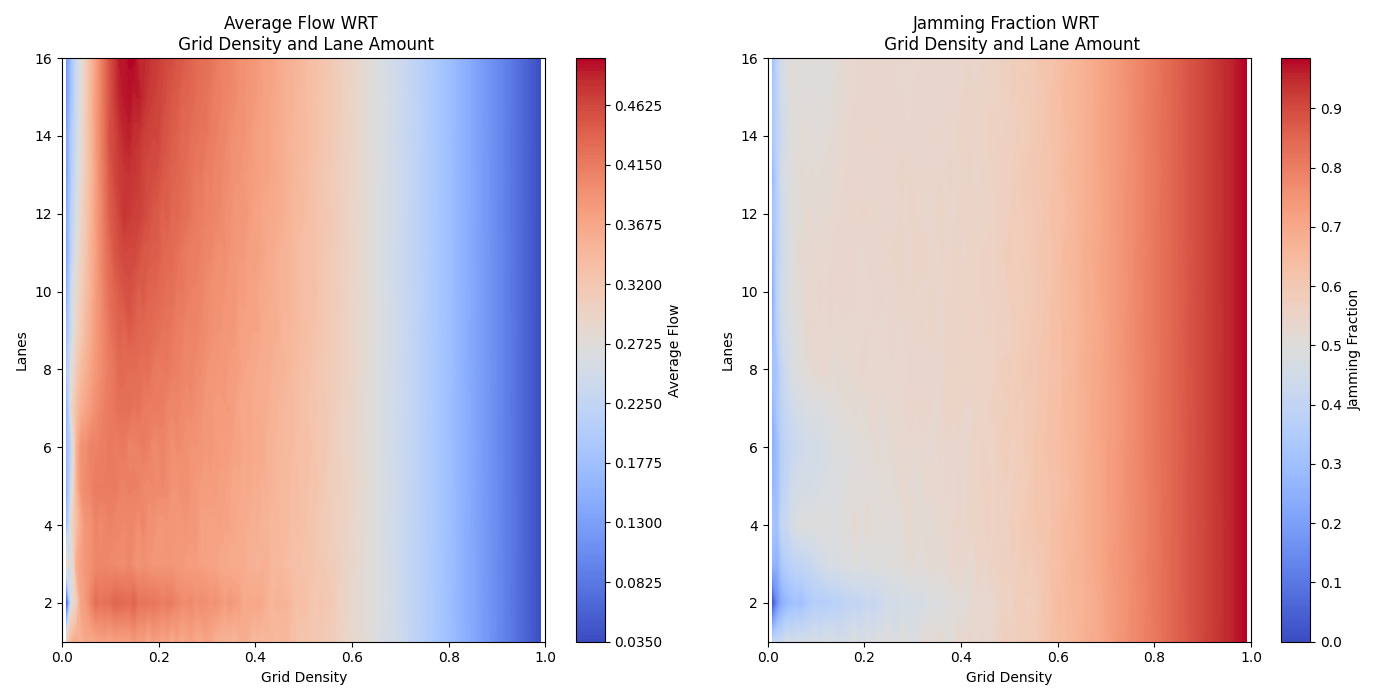

In [189]:
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(122)


ay = fig.add_subplot(121)


cf1 = ay.contourf(density, lane, average_flows, cmap='coolwarm', levels = 200)

ay.set_xlabel('Grid Density')
ay.set_ylabel('Lanes')
ay.set_title('Average Flow WRT \n Grid Density and Lane Amount')
ay.set_xlim(0,1)
ay.set_ylim(1,16)



cf2 = ax.contourf(density, lane, jamming_fractions, cmap='coolwarm', levels = 200)

ax.set_xlabel('Grid Density')
ax.set_ylabel('Lanes')
ax.set_title('Jamming Fraction WRT \n Grid Density and Lane Amount')
ax.set_xlim(0,1)
ax.set_ylim(1,16)

fig.colorbar(cf1, ax = ay, label='Average Flow')
fig.colorbar(cf2, ax = ax, label='Jamming Fraction')

plt.subplots_adjust(wspace=0.5)
plt.tight_layout()
plt.show()